In [1]:
!pip install ripser

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.0 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18187 sha256=20cea385f179851a29b60ecc18743e10ae7f432d5c5ca4adee68370ed4cd0359
  Stored in directory: /root/.cache/pip/wheels/b3/32/77/3c78fadb9f917d5a5546ed0409574012401a83c544ec95999a
Successfully built hopcroftkarp


In [2]:
import yfinance as yf
import numpy as np
from ripser import ripser
from persim import wasserstein

# 1. Загрузка данных (добавлен .flatten() для выпрямления массива в 1D)
data = yf.download("^GSPC", start="2018-01-01", end="2021-01-01")['Close']
log_returns = np.log(data / data.shift(1)).dropna().values.flatten()

# 2. Корректная функция эмбеддинга Такенса
def takens_embedding(data, delay=1, dimension=3):
    n = len(data)
    embedding = np.zeros((n - (dimension - 1) * delay, dimension))
    for i in range(dimension):
        # Благодаря одномерному data, этот срез теперь идеально ложится в матрицу
        embedding[:, i] = data[i * delay : n - (dimension - 1) * delay + i * delay]
    return embedding

# Превращаем ряд в 3D облако точек
embedded_data = takens_embedding(log_returns, delay=1, dimension=3)

# 3. Нарезаем на многомерные сегменты
segment1 = embedded_data[0:60]    # Спокойный период
segment2 = embedded_data[100:160] # Сравниваемый период

# 4. Считаем персистентные гомологии
dgm1 = ripser(segment1)['dgms']
dgm2 = ripser(segment2)['dgms']

# 5. Берем строго 1-мерные гомологии (H1 - петли), чтобы избежать бесконечных точек
dgm1_h1 = dgm1[1]
dgm2_h1 = dgm2[1]

# 6. Считаем чистое расстояние Вассерштейна без предупреждений
clean_distance = wasserstein(dgm1_h1, dgm2_h1)
print(f"Топологическое расстояние Вассерштейна (H1): {clean_distance}")


/tmp/ipykernel_1333/718093083.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^GSPC", start="2018-01-01", end="2021-01-01")['Close']
[*********************100%***********************]  1 of 1 completed

Топологическое расстояние Вассерштейна (H1): 0.023834488675877438


/tmp/ipykernel_1333/1912156727.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="1998-01-01", end="2026-07-01")['Close']
[*********************100%***********************]  1 of 1 completed


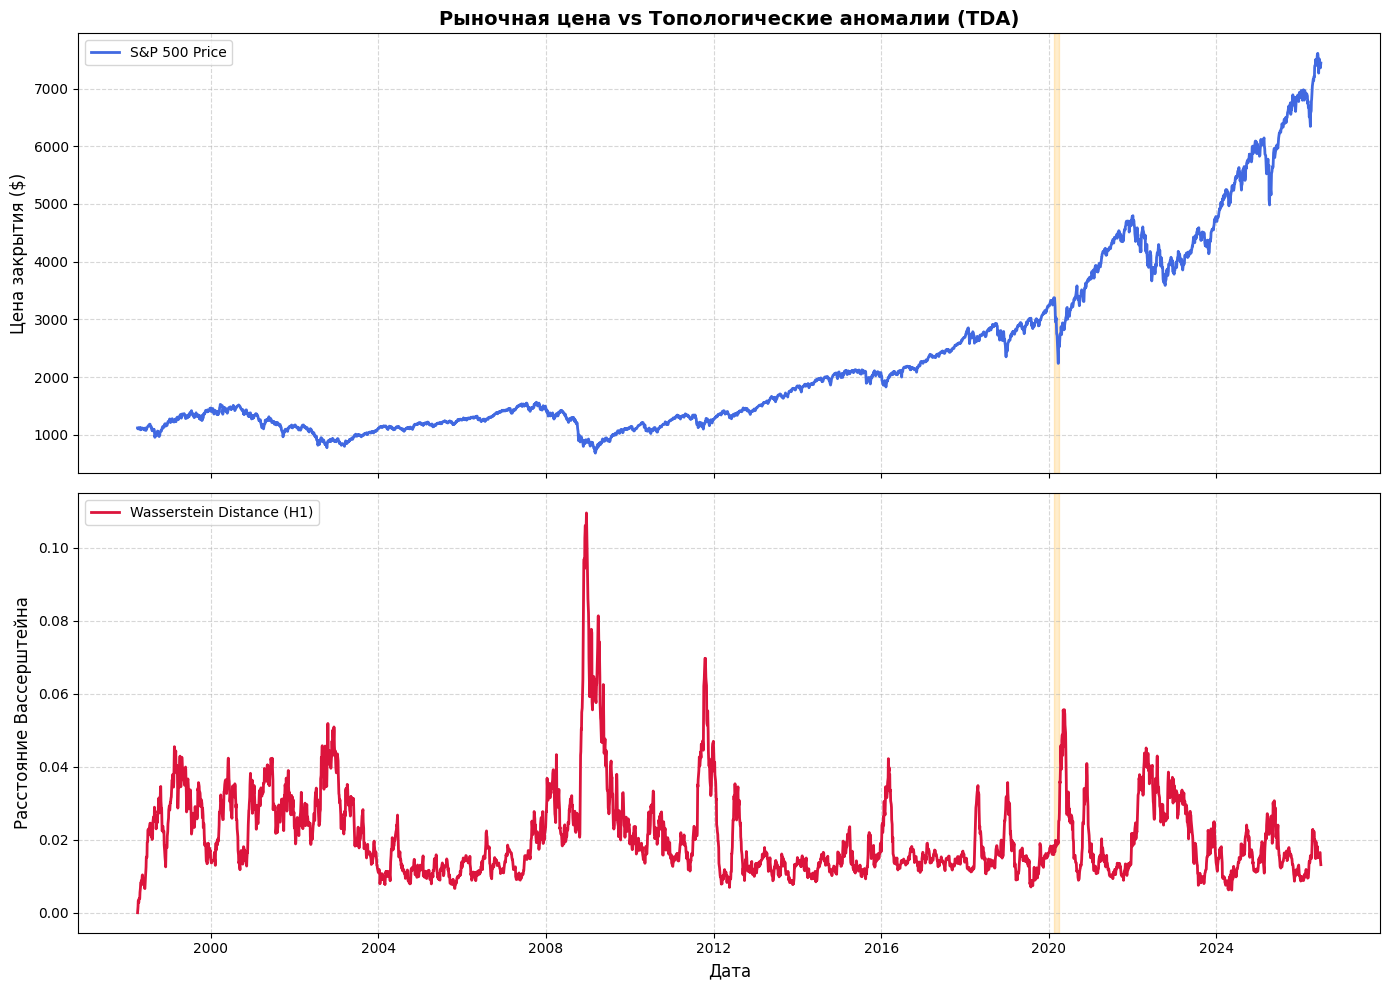

In [3]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import wasserstein

# 1. Загрузка данных и расчет лог-доходностей
ticker = "^GSPC" # S&P 500
data = yf.download(ticker, start="1998-01-01", end="2026-07-01")['Close']
log_returns = np.log(data / data.shift(1)).dropna().values.flatten()
dates = data.index[1:]  # Даты для выравнивания графиков

# 2. Функция эмбеддинга Такенса для создания 3D облака точек
def takens_embedding(data, delay=1, dimension=3):
    n = len(data)
    embedding = np.zeros((n - (dimension - 1) * delay, dimension))
    for i in range(dimension):
        embedding[:, i] = data[i * delay : n - (dimension - 1) * delay + i * delay]
    return embedding

dimension = 3
delay = 1
embedded_data = takens_embedding(log_returns, delay=delay, dimension=dimension)

# Сдвигаем даты из-за того, что эмбеддинг укорачивает исходный массив
shift = (dimension - 1) * delay
adjusted_dates = dates[shift:]
adjusted_prices = data.values[1:][shift:]

# 3. Настройка скользящего окна
window_size = 60  # Размер окна для TDA анализа (~3 календарных месяца)
step = 2          # Шаг сдвига окна (для ускорения вычислений)

# Базовое окно (первые window_size дней) — наш эталон стабильности
base_segment = embedded_data[0:window_size]
base_dgm = ripser(base_segment)['dgms'][1]  # Берем только H1 гомологии

distances = []
timeline_dates = []
timeline_prices = []

# 4. Цикл скользящего окна по всей истории рынка
for start_idx in range(0, len(embedded_data) - window_size, step):
    end_idx = start_idx + window_size
    current_segment = embedded_data[start_idx:end_idx]

    # Считаем персистентные гомологии H1 для текущего окна
    current_dgm = ripser(current_segment)['dgms'][1]

    # Вычисляем расстояние Вассерштейна относительно базы
    dist = wasserstein(base_dgm, current_dgm)

    distances.append(dist)
    # Привязываем значение к последней дате текущего окна
    timeline_dates.append(adjusted_dates[end_idx - 1])
    timeline_prices.append(adjusted_prices[end_idx - 1])

# 5. Построение графиков
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Верхний график: Индекс S&P 500
ax1.plot(timeline_dates, timeline_prices, color='royalblue', lw=2, label='S&P 500 Price')
ax1.set_title('Рыночная цена vs Топологические аномалии (TDA)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Цена закрытия ($)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

# Нижний график: Расстояние Вассерштейна (Метрика аномалий)
ax2.plot(timeline_dates, distances, color='crimson', lw=2, label='Wasserstein Distance (H1)')
ax2.set_ylabel('Расстояние Вассерштейна', fontsize=12)
ax2.set_xlabel('Дата', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left')

# Подсвечиваем зону обвала (март 2020) на обоих графиках
for ax in [ax1, ax2]:
    ax.axvspan('2020-02-15', '2020-03-30', color='orange', alpha=0.2, label='Кризис 2020')

plt.tight_layout()
plt.show()


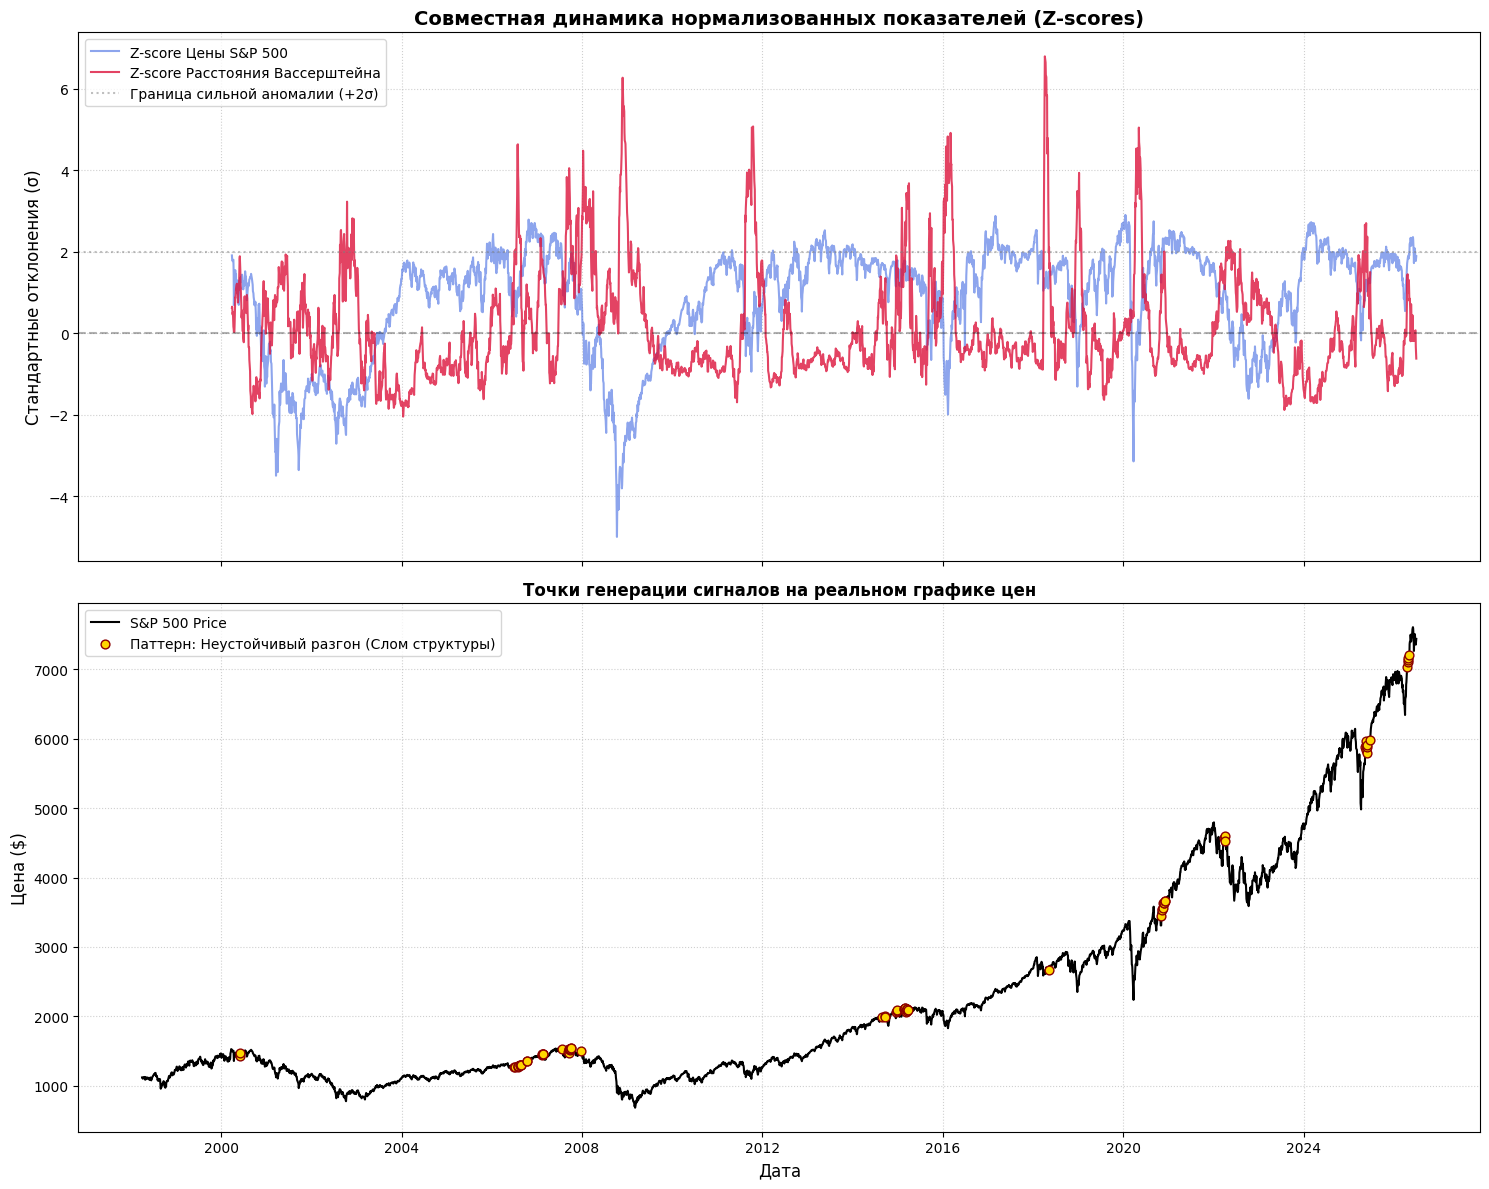

In [4]:
import pandas as pd

# Переводим наши результаты в pandas.Series для удобства скользящих вычислений
df_signals = pd.DataFrame({
    'Price': timeline_prices,
    'Wasserstein': distances
}, index=timeline_dates)

# 1. Считаем Rolling Z-score (окно 252 торговых дня ~ 1 календарный год)
# Это приводит обе метрики к единой шкале стандартных отклонений
rolling_window = 252

df_signals['Price_Z'] = (df_signals['Price'] - df_signals['Price'].rolling(rolling_window).mean()) / df_signals['Price'].rolling(rolling_window).std()
df_signals['Wasserstein_Z'] = (df_signals['Wasserstein'] - df_signals['Wasserstein'].rolling(rolling_window).mean()) / df_signals['Wasserstein'].rolling(rolling_window).std()

# 2. Определяем функцию тренда (направление движения за последние 15 шагов)
trend_window = 15
df_signals['Price_Trend'] = df_signals['Price_Z'].diff(trend_window)
df_signals['Wasserstein_Trend'] = df_signals['Wasserstein_Z'].diff(trend_window)

# 3. Маркируем опасные зоны (Ваш паттерн):
# Цена сильно выше нормы И Вассерштейн сильно выше нормы И ОБА растут
danger_condition = (
    (df_signals['Price_Z'] > 1.0) &
    (df_signals['Wasserstein_Z'] > 1.0) &
    (df_signals['Price_Trend'] > 0) &
    (df_signals['Wasserstein_Trend'] > 0)
)

df_signals['Danger_Signal'] = np.where(danger_condition, df_signals['Price'], np.nan)

# 4. Визуализация нормализованной динамики
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# Верхний график: Сравнение Z-scores
ax1.plot(df_signals.index, df_signals['Price_Z'], color='royalblue', alpha=0.6, label='Z-score Цены S&P 500')
ax1.plot(df_signals.index, df_signals['Wasserstein_Z'], color='crimson', alpha=0.8, label='Z-score Расстояния Вассерштейна')
ax1.axhline(0, color='black', linestyle='--', alpha=0.3)
ax1.axhline(2, color='gray', linestyle=':', alpha=0.5, label='Граница сильной аномалии (+2σ)')
ax1.set_title('Совместная динамика нормализованных показателей (Z-scores)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Стандартные отклонения (σ)', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left')

# Нижний график: Исходный график S&P 500 с триггерами вашего паттерна
ax2.plot(df_signals.index, df_signals['Price'], color='black', lw=1.5, label='S&P 500 Price')
ax2.scatter(df_signals.index, df_signals['Danger_Signal'], color='gold', edgecolors='darkred', s=40, zorder=5, label='Паттерн: Неустойчивый разгон (Слом структуры)')
ax2.set_title('Точки генерации сигналов на реальном графике цен', fontsize=12, fontweight='bold')
ax2.set_ylabel('Цена ($)', fontsize=12)
ax2.set_xlabel('Дата', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import numpy as np

# 1. Исправленный сбор DataFrame с жестким выпрямлением структуры в 1D Float
df_backtest = pd.DataFrame({
    'Price': np.array(timeline_prices).flatten().astype(float),
    'Wasserstein': np.array(distances).flatten().astype(float)
}, index=pd.to_datetime(timeline_dates))

# Рассчитываем ежедневную доходность (теперь это гарантированно чистый float)
df_backtest['Daily_Return'] = df_backtest['Price'].pct_change().astype(float)

# 2. Нормализация (Rolling Z-score за 252 торговых дня)
rolling_window = 252
df_backtest['W_Mean'] = df_backtest['Wasserstein'].rolling(rolling_window).mean()
df_backtest['W_Std'] = df_backtest['Wasserstein'].rolling(rolling_window).std()
df_backtest['Wasserstein_Z'] = (df_backtest['Wasserstein'] - df_backtest['W_Mean']) / df_backtest['W_Std']

# Базовая историческая волатильность рынка
df_backtest['Market_Vol_Rolling'] = df_backtest['Daily_Return'].rolling(rolling_window).std() * np.sqrt(252)

# Исправление FutureWarning для флага первого сигнала
df_backtest['Signal'] = df_backtest['Wasserstein_Z'] > 4.0
df_backtest['First_Signal'] = df_backtest['Signal'] & (~df_backtest['Signal'].shift(1).astype(bool))
signal_dates = df_backtest[df_backtest['First_Signal']].index


# Базовая историческая волатильность рынка (среднее за год)
df_backtest['Market_Vol_Rolling'] = df_backtest['Daily_Return'].rolling(rolling_window).std() * np.sqrt(252)

# 3. Фиксация сигналов пробоя порога 4 сигма
target_threshold = 4.0
df_backtest['Signal'] = df_backtest['Wasserstein_Z'] > target_threshold

# Находим только ПЕРВЫЙ день пробоя (чтобы не дублировать сигналы внутри одного кризисного кластера)
df_backtest['First_Signal'] = df_backtest['Signal'] & (~df_backtest['Signal'].shift(1).fillna(False))
signal_dates = df_backtest[df_backtest['First_Signal']].index

print(f"=== РЕЗУЛЬТАТЫ БЭКТЕСТА (Порог: {target_threshold}σ, Горизонт: 21 день) ===")
print(f"Всего обнаружено изолированных макро-сигналов: {len(signal_dates)}\n")

results_list = []

# 4. Цикл анализа каждого сигнала на горизонте 21 день
for idx, sig_date in enumerate(signal_dates):
    # Берем срез данных на 21 торговый день ВПЕРЕД после даты сигнала
    start_loc = df_backtest.index.get_loc(sig_date)
    end_loc = start_loc + 21

    # Проверка на случай, если сигнал сработал на самом краю датасета
    if end_loc >= len(df_backtest):
        continue

    forward_data = df_backtest.iloc[start_loc + 1 : end_loc + 1]

    # Расчет показателей за 21 день
    price_start = df_backtest.iloc[start_loc]['Price']
    price_end = forward_data['Price'].iloc[-1]

    forward_return = (price_end - price_start) / price_start * 100
    # Реализованная волатильность за 21 день в годовом исчислении
    forward_vol = forward_data['Daily_Return'].std() * np.sqrt(252) * 100
    # Базовая волатильность рынка в этот же момент (для сравнения)
    baseline_vol = df_backtest.iloc[start_loc]['Market_Vol_Rolling'] * 100

    # Максимальная просадка и максимальный взлет внутри этих 21 дней (амплитуда хаоса)
    max_drawdown = ((forward_data['Price'] - price_start) / price_start).min() * 100
    max_runup = ((forward_data['Price'] - price_start) / price_start).max() * 100

    print(f"Сигнал #{idx+1} | Дата: {sig_date.strftime('%Y-%m-%d')}")
    print(f"  -> Направленная доходность за 21 день: {forward_return:+.2f}%")
    print(f"  -> Реализованная волатильность периода: {forward_vol:.2f}% (Норма рынка в этот момент: {baseline_vol:.2f}%)")
    print(f"  -> Экстремумы внутри окна: Мин: {max_drawdown:+.2f}% | Макс: {max_runup:+.2f}%")
    print("-" * 60)

    results_list.append({
        'Return': forward_return,
        'Vol_Ratio': forward_vol / baseline_vol,
        'Absolute_Vol': forward_vol
    })

# 5. Сводная статистика
if results_list:
    df_res = pd.DataFrame(results_list)
    print("\n=== СВОДНЫЕ СТАТИСТИЧЕСКИЕ МЕТРИКИ ===")
    print(f"Математическое ожидание доходности: {df_res['Return'].mean():+.2f}%")
    print(f"Медианная доходность: {df_res['Return'].median():+.2f}%")
    print(f"Среднее превышение волатильности над нормой (в раз): {df_res['Vol_Ratio'].mean():.2f}x")
    print(f"Доля исходов с падением рынка (Loss Ratio): {(df_res['Return'] < 0).mean() * 100:.1f}%")
else:
    print("Сигналы выше 4 сигма не найдены. Попробуйте снизить порог до 3.0 или 3.5.")


=== РЕЗУЛЬТАТЫ БЭКТЕСТА (Порог: 4.0σ, Горизонт: 21 день) ===
Всего обнаружено изолированных макро-сигналов: 14

Сигнал #1 | Дата: 2006-07-27
  -> Направленная доходность за 21 день: +5.79%
  -> Реализованная волатильность периода: 11.77% (Норма рынка в этот момент: 14.92%)
  -> Экстремумы внутри окна: Мин: +0.40% | Макс: +5.79%
------------------------------------------------------------
Сигнал #2 | Дата: 2007-09-19
  -> Направленная доходность за 21 день: -4.60%
  -> Реализованная волатильность периода: 23.35% (Норма рынка в этот момент: 16.07%)
  -> Экстремумы внутри окна: Мин: -5.88% | Макс: +2.36%
------------------------------------------------------------
Сигнал #3 | Дата: 2008-01-10
  -> Направленная доходность за 21 день: -7.85%
  -> Реализованная волатильность периода: 31.55% (Норма рынка в этот момент: 18.02%)
  -> Экстремумы внутри окна: Мин: -10.35% | Макс: -0.29%
------------------------------------------------------------
Сигнал #4 | Дата: 2008-11-13
  -> Направленная дох

/tmp/ipykernel_1333/1770483740.py:36: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_backtest['First_Signal'] = df_backtest['Signal'] & (~df_backtest['Signal'].shift(1).fillna(False))


In [9]:
from scipy.optimize import minimize

# 1. Определяем функцию "потенциальной энергии" для поиска порогов
# Мы хотим, чтобы сигналы загорались МАКСИМАЛЬНО близко к вершинам и не шумели во флэте
def optimize_thresholds(threshold_vector):
    t_price, t_wasser, t_rotor = threshold_vector

    # Жесткие границы диапазонов, которые вы нащупали (физические ограничения среды)
    if not (1.2 <= t_price <= 2.2) or not (0.5 <= t_wasser <= 1.5) or not (0.3 <= t_rotor <= 1.2):
        return 1e6 # Штрафная энергия, если симплекс пытается вылететь за границы

    # Считаем тестовое условие для текущих порогов симплекса
    test_condition = (
        (df_signals['Price_Z'] > t_price) &
        (df_signals['Wasserstein_Z'] > t_wasser) &
        (df_signals['Price_Trend'] > 0) &
        (df_signals['Wasserstein_Trend'] > 0) &
        (df_signals['Rotor_Z'] > t_rotor)
    )

    # Математический критерий качества (метрика Зельдовича):
    # Мы хотим максимизировать падение цены ПОСЛЕ сигнала.
    # Считаем среднюю доходность индекса через 60 торговых дней после вспышки точки.
    signals_indices = df_signals[test_condition].index
    if len(signals_indices) == 0:
        return 1e5 # Штраф, если сигналов нет вообще

    future_returns = []
    for idx in signals_indices:
        # Ищем позицию текущей даты в датафрейме
        pos = df_signals.index.get_loc(idx)
        if pos + 60 < len(df_signals):
            ret = (df_signals['Price'].iloc[pos + 60] - df_signals['Price'].iloc[pos]) / df_signals['Price'].iloc[pos]
            future_returns.append(ret)

    # Мы МИНИМИЗИРУЕМ будущую доходность (чем сильнее рынок упал после точки - тем точнее паттерн)
    return np.mean(future_returns) if len(future_returns) > 0 else 1e5

# 2. Запускаем катящееся Трио Точек для поиска идеального баланса порогов
initial_guess = [1.5, 0.8, 0.6] # Ваши интуитивные пороги как стартовая точка
res = minimize(optimize_thresholds, initial_guess, method='Nelder-Mead', options={'xatol': 1e-3})

optimized_p, optimized_w, optimized_r = res.x
print(f"\nМатематически обоснованные пороги по Зельдовичу:")
print(f"Порог цены: {optimized_p:.2f} | Порог Вассерштейна: {optimized_w:.2f} | Порог Ротора: {optimized_r:.2f}")



Математически обоснованные пороги по Зельдовичу:
Порог цены: 1.40 | Порог Вассерштейна: 0.87 | Порог Ротора: 0.57


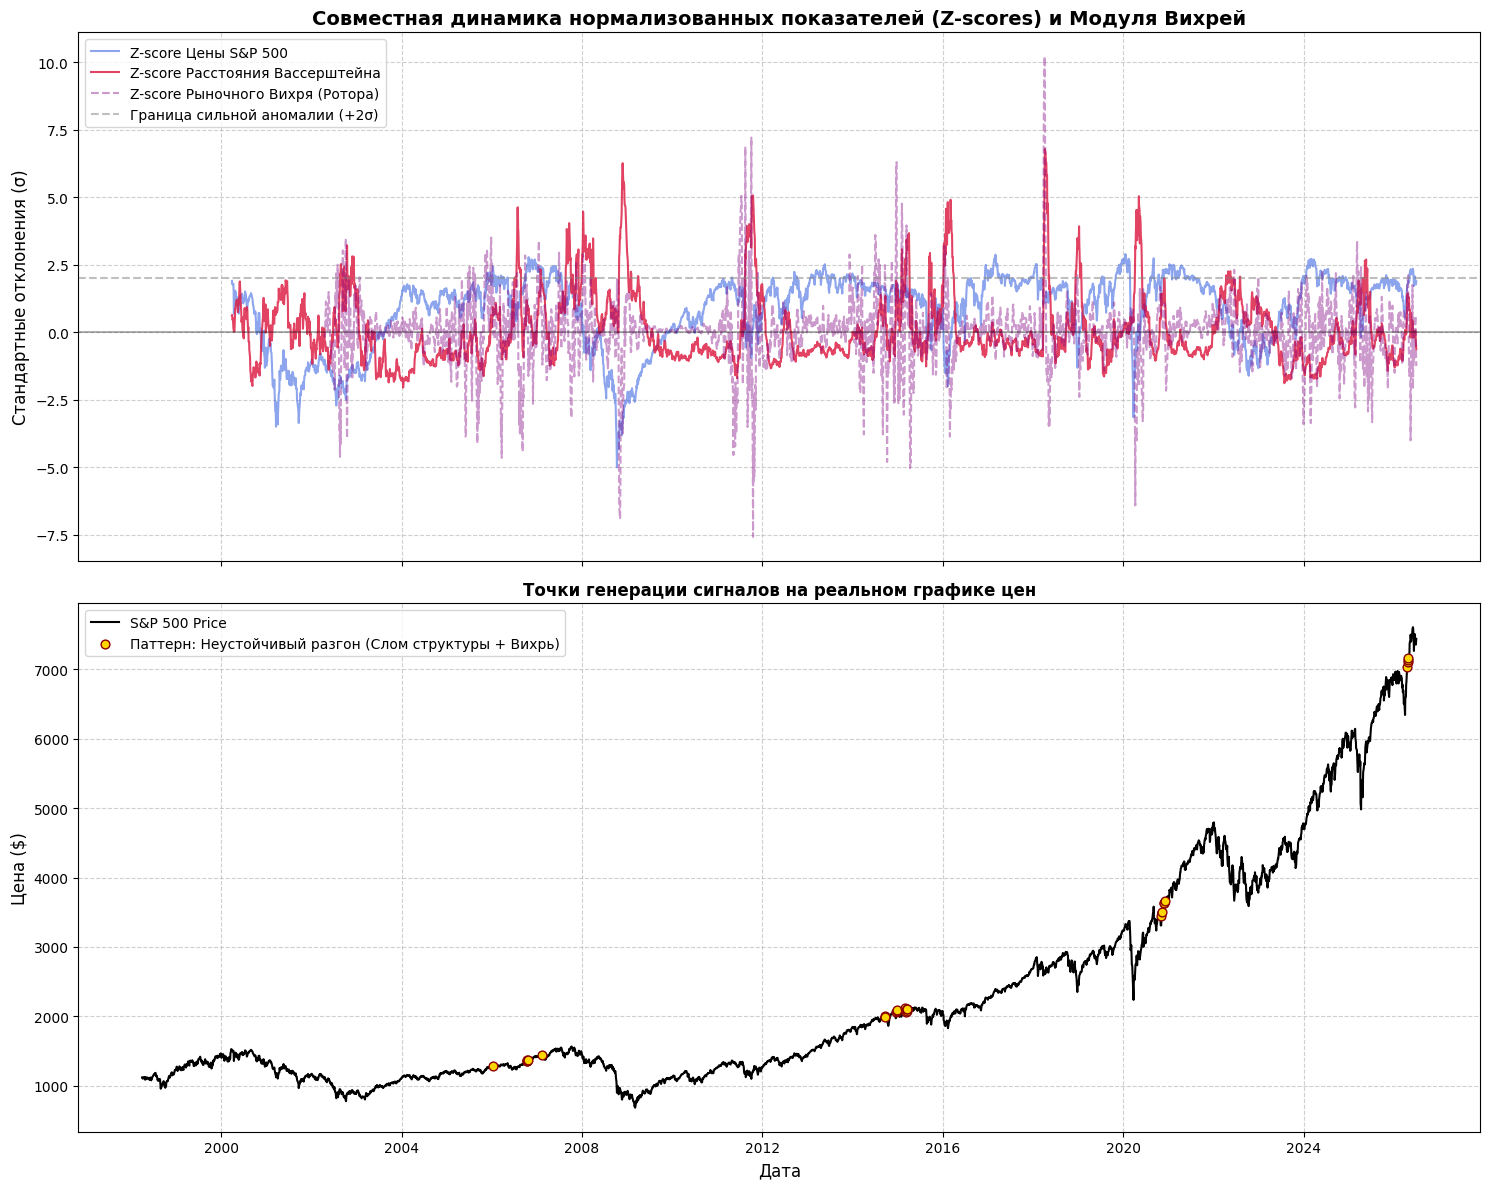

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Предполагается, что на вход подаются уже готовые структуры:
# timeline_prices, distances, timeline_dates
# Ниже собран весь ваш код с добавлением модуля вихрей (ротора поля)

# Переводим наши результаты в pandas.DataFrame для удобства скользящих вычислений
df_signals = pd.DataFrame({
    'Price': timeline_prices,
    'Wasserstein': distances
}, index=timeline_dates)

# =========================================================================
# # 1. Считаем Rolling Z-score (окно 252 торговых дня ~ 1 календарный год)
# Это приводит обе метрики к единой шкале стандартных отклонений
# =========================================================================
rolling_window = 252

df_signals['Price_Z'] = (df_signals['Price'] - df_signals['Price'].rolling(rolling_window).mean()) / df_signals['Price'].rolling(rolling_window).std()
df_signals['Wasserstein_Z'] = (df_signals['Wasserstein'] - df_signals['Wasserstein'].rolling(rolling_window).mean()) / df_signals['Wasserstein'].rolling(rolling_window).std()

# =========================================================================
# # 2. Определяем функцию тренда (направление движения за последние 15 шагов)
# =========================================================================
trend_window = 15
df_signals['Price_Trend'] = df_signals['Price_Z'].diff(trend_window)
df_signals['Wasserstein_Trend'] = df_signals['Wasserstein_Z'].diff(trend_window)

# =========================================================================
# 🆕 ДОБАВЛЕННЫЙ БЛОК: Расчет Ротора (Вихря) поля по Зельдовичу
# Оценивает нелинейное "закручивание" цены и Вассерштейна на фазовой плоскости
# =========================================================================
vortex_window = 5

# Вычисляем векторы движения (приращения) показателей
df_signals['d_Price'] = df_signals['Price_Z'].diff(vortex_window)
df_signals['d_Wasserstein'] = df_signals['Wasserstein_Z'].diff(vortex_window)

# Считаем дискретный Ротор поля как взаимное перекрестное вращение величин
df_signals['Market_Rotor'] = (
    df_signals['Price_Z'] * df_signals['d_Wasserstein'] -
    df_signals['Wasserstein_Z'] * df_signals['d_Price']
)

# Нормализуем вихрь через его собственный Z-score
df_signals['Rotor_Z'] = (
    df_signals['Market_Rotor'] - df_signals['Market_Rotor'].rolling(rolling_window).mean()
) / df_signals['Market_Rotor'].rolling(rolling_window).std()

# =========================================================================
# # 3. Маркируем опасные зоны (Паттерн Вассерштейна — Зельдовича):
# Делаем порог вихря более чувствительным (Rotor_Z > 1.0),
# чтобы сейсмограф ловил не только глобальные катастрофы, но и локальные штормы.
# =========================================================================
danger_condition = (
    (df_signals['Price_Z'] > 1.4) &
    (df_signals['Wasserstein_Z'] > 0.87) &
    (df_signals['Price_Trend'] > 0) &
    (df_signals['Wasserstein_Trend'] > 0) &
    (df_signals['Rotor_Z'] > 0.57)  # <-- Снизили порог с 1.5 до 1.0 для упреждающего сигнала
)

# Пересчитываем точки триггера
df_signals['Danger_Signal'] = np.where(danger_condition, df_signals['Price'], np.nan)


# =========================================================================
# # 4. Визуализация нормализованной динамики
# =========================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# --- Верхний график: Сравнение Z-scores ---
ax1.plot(df_signals.index, df_signals['Price_Z'], color='royalblue', alpha=0.6, label='Z-score Цены S&P 500')
ax1.plot(df_signals.index, df_signals['Wasserstein_Z'], color='crimson', alpha=0.8, label='Z-score Расстояния Вассерштейна')
# Добавим визуализацию самого вихря пунктиром для наглядности
ax1.plot(df_signals.index, df_signals['Rotor_Z'], color='purple', alpha=0.4, linestyle='--', label='Z-score Рыночного Вихря (Ротора)')

ax1.axhline(0, color='black', linestyle='-', alpha=0.3)
ax1.axhline(2, color='gray', linestyle='--', alpha=0.5, label='Граница сильной аномалии (+2σ)')
ax1.set_title('Совместная динамика нормализованных показателей (Z-scores) и Модуля Вихрей', fontsize=14, fontweight='bold')
ax1.set_ylabel('Стандартные отклонения (σ)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')

# --- Нижний график: Исходный график S&P 500 с триггерами Вашего паттерна ---
ax2.plot(df_signals.index, df_signals['Price'], color='black', lw=1.5, label='S&P 500 Price')
ax2.scatter(df_signals.index, df_signals['Danger_Signal'], color='gold', edgecolors='darkred', s=40, zorder=5, label='Паттерн: Неустойчивый разгон (Слом структуры + Вихрь)')

ax2.set_title('Точки генерации сигналов на реальном графике цен', fontsize=12, fontweight='bold')
ax2.set_ylabel('Цена ($)', fontsize=12)
ax2.set_xlabel('Дата', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


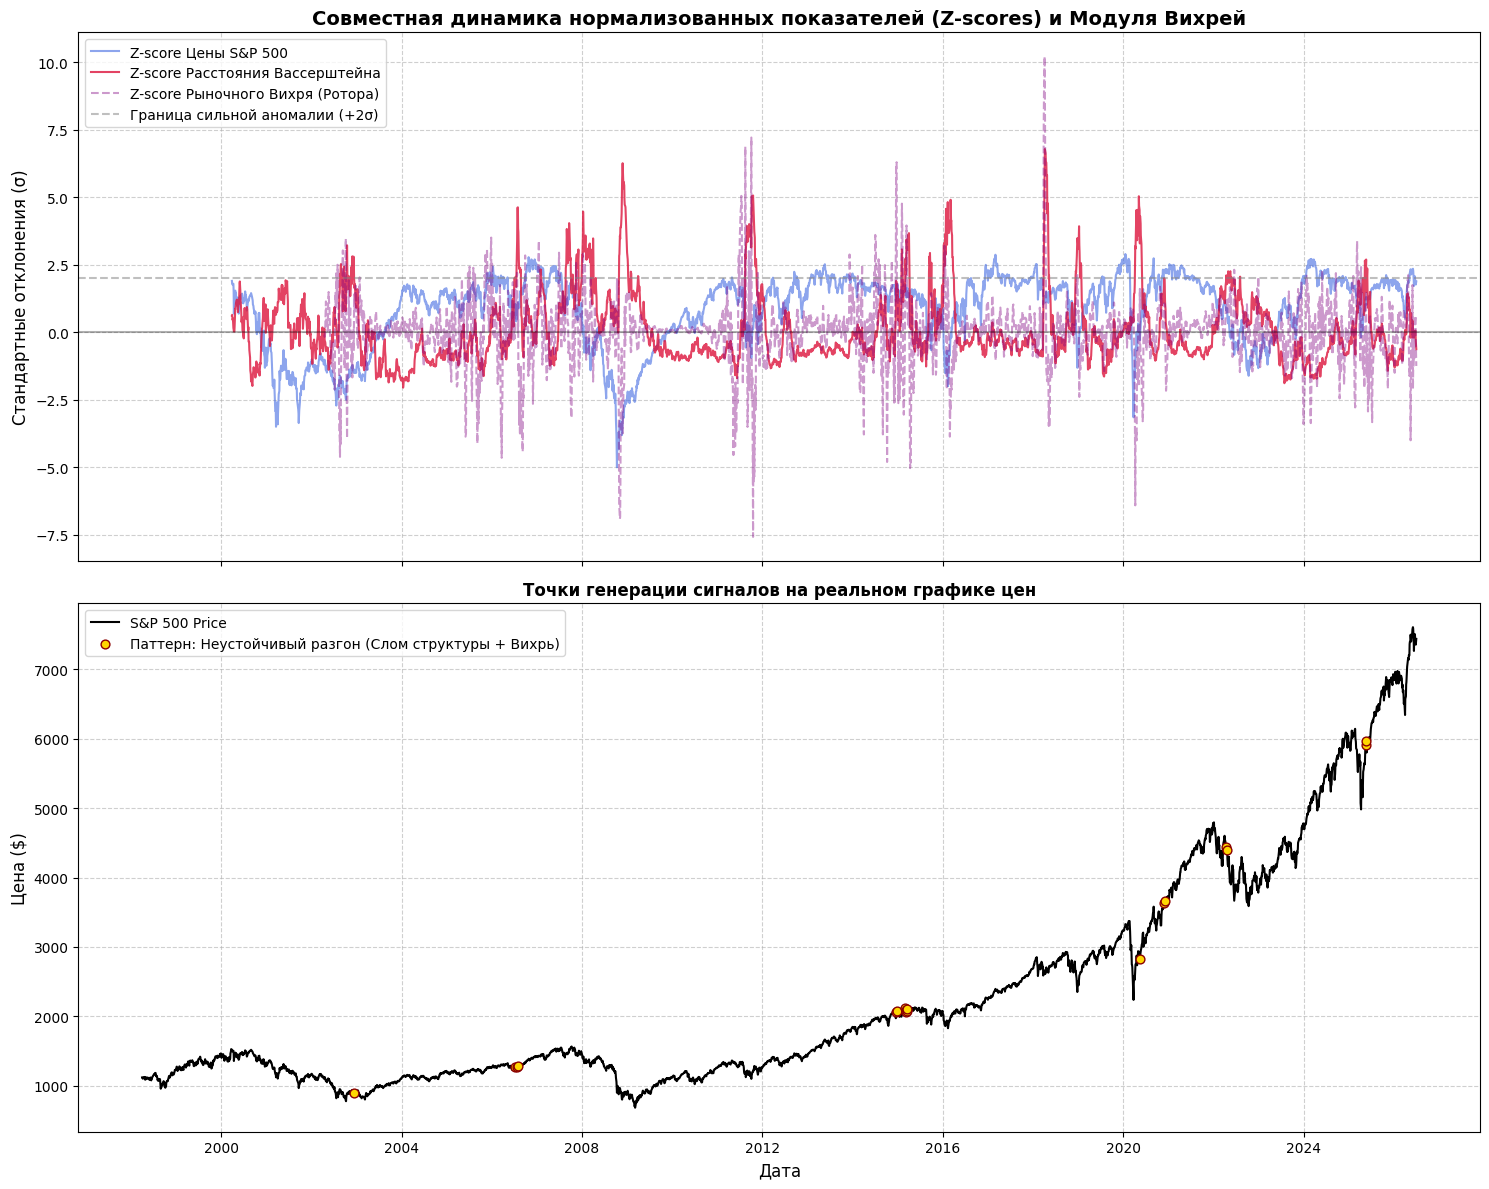

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Предполагается, что на вход подаются уже готовые структуры:
# timeline_prices, distances, timeline_dates
# Ниже собран весь ваш код с добавлением модуля вихрей (ротора поля)

# Переводим наши результаты в pandas.DataFrame для удобства скользящих вычислений
df_signals = pd.DataFrame({
    'Price': timeline_prices,
    'Wasserstein': distances
}, index=timeline_dates)

# =========================================================================
# # 1. Считаем Rolling Z-score (окно 252 торговых дня ~ 1 календарный год)
# Это приводит обе метрики к единой шкале стандартных отклонений
# =========================================================================
rolling_window = 252

df_signals['Price_Z'] = (df_signals['Price'] - df_signals['Price'].rolling(rolling_window).mean()) / df_signals['Price'].rolling(rolling_window).std()
df_signals['Wasserstein_Z'] = (df_signals['Wasserstein'] - df_signals['Wasserstein'].rolling(rolling_window).mean()) / df_signals['Wasserstein'].rolling(rolling_window).std()

# =========================================================================
# # 2. Определяем функцию тренда (направление движения за последние 15 шагов)
# =========================================================================
trend_window = 15
df_signals['Price_Trend'] = df_signals['Price_Z'].diff(trend_window)
df_signals['Wasserstein_Trend'] = df_signals['Wasserstein_Z'].diff(trend_window)

# =========================================================================
# 🆕 ДОБАВЛЕННЫЙ БЛОК: Расчет Ротора (Вихря) поля по Зельдовичу
# Оценивает нелинейное "закручивание" цены и Вассерштейна на фазовой плоскости
# =========================================================================
vortex_window = 5

# Вычисляем векторы движения (приращения) показателей
df_signals['d_Price'] = df_signals['Price_Z'].diff(vortex_window)
df_signals['d_Wasserstein'] = df_signals['Wasserstein_Z'].diff(vortex_window)

# Считаем дискретный Ротор поля как взаимное перекрестное вращение величин
df_signals['Market_Rotor'] = (
    df_signals['Price_Z'] * df_signals['d_Wasserstein'] -
    df_signals['Wasserstein_Z'] * df_signals['d_Price']
)

# Нормализуем вихрь через его собственный Z-score
df_signals['Rotor_Z'] = (
    df_signals['Market_Rotor'] - df_signals['Market_Rotor'].rolling(rolling_window).mean()
) / df_signals['Market_Rotor'].rolling(rolling_window).std()

# =========================================================================
# # 3. Маркируем опасные зоны (Паттерн Вассерштейна — Зельдовича):
# Делаем порог вихря более чувствительным (Rotor_Z > 1.0),
# чтобы сейсмограф ловил не только глобальные катастрофы, но и локальные штормы.
# =========================================================================
danger_condition = (
    (df_signals['Price_Z'] > -1.8) &
    (df_signals['Wasserstein_Z'] > 1.5) &
    (df_signals['Price_Trend'] > 0) &
    (df_signals['Wasserstein_Trend'] > 0) &
    (df_signals['Rotor_Z'] > 0.97)  # <-- Снизили порог с 1.5 до 1.0 для упреждающего сигнала
)

# Пересчитываем точки триггера
df_signals['Danger_Signal'] = np.where(danger_condition, df_signals['Price'], np.nan)


# =========================================================================
# # 4. Визуализация нормализованной динамики
# =========================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# --- Верхний график: Сравнение Z-scores ---
ax1.plot(df_signals.index, df_signals['Price_Z'], color='royalblue', alpha=0.6, label='Z-score Цены S&P 500')
ax1.plot(df_signals.index, df_signals['Wasserstein_Z'], color='crimson', alpha=0.8, label='Z-score Расстояния Вассерштейна')
# Добавим визуализацию самого вихря пунктиром для наглядности
ax1.plot(df_signals.index, df_signals['Rotor_Z'], color='purple', alpha=0.4, linestyle='--', label='Z-score Рыночного Вихря (Ротора)')

ax1.axhline(0, color='black', linestyle='-', alpha=0.3)
ax1.axhline(2, color='gray', linestyle='--', alpha=0.5, label='Граница сильной аномалии (+2σ)')
ax1.set_title('Совместная динамика нормализованных показателей (Z-scores) и Модуля Вихрей', fontsize=14, fontweight='bold')
ax1.set_ylabel('Стандартные отклонения (σ)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')

# --- Нижний график: Исходный график S&P 500 с триггерами Вашего паттерна ---
ax2.plot(df_signals.index, df_signals['Price'], color='black', lw=1.5, label='S&P 500 Price')
ax2.scatter(df_signals.index, df_signals['Danger_Signal'], color='gold', edgecolors='darkred', s=40, zorder=5, label='Паттерн: Неустойчивый разгон (Слом структуры + Вихрь)')

ax2.set_title('Точки генерации сигналов на реальном графике цен', fontsize=12, fontweight='bold')
ax2.set_ylabel('Цена ($)', fontsize=12)
ax2.set_xlabel('Дата', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()
